In [1]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [2]:
training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

100.0%
100.0%
100.0%
100.0%

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


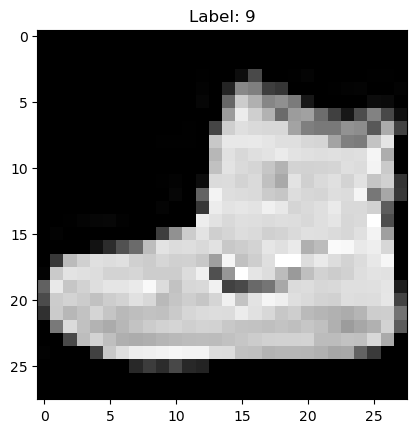

In [3]:
img, label = training_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [4]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test, minacc=None):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    if not minacc:
        minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

#### CNN

In [5]:
class CNN(torch.nn.Module):
    
    def __init__(self, nhidden1=256, nhidden2=64, noutput=10):
        super(CNN, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Linear(7*7*64, nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [6]:
model = CNN()

In [7]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
            Conv2d-6           [-1, 64, 14, 14]          18,496
              ReLU-7           [-1, 64, 14, 14]               0
            Conv2d-8           [-1, 64, 14, 14]          36,928
              ReLU-9           [-1, 64, 14, 14]               0
        MaxPool2d-10             [-1, 64, 7, 7]               0
          Flatten-11                 [-1, 3136]               0
           Linear-12                  [-1, 256]         803,072
             ReLU-13                  [-1, 256]               0
           Linear-14                   

#### GPU

In [8]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(device)

mps


In [9]:
def train_val(model, cost, epochs, train_loader, val_loader, optimizer, device):
    model = model.to(device)
    cost = cost.to(device)
    
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []    
    train_samples = len(train_loader.dataset)
    val_samples = len(val_loader.dataset)
    train_batches = len(train_loader)
    val_batches = len(val_loader)
    for epoch in range(nepochs):
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(train_loader):
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
    
            # gradient, parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        cost /= train_batches
        acc /= train_samples
    
        cost_val, acc_val = 0.0, 0.0
        with torch.no_grad():
            for batch, (X, Y) in enumerate(val_loader): 
                X, Y = X.to(device), Y.to(device)
                pred = model(X)
                cost_val += cost_ce(pred, Y).item()
                acc_val += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            cost_val /= val_batches
            acc_val /= val_samples
        
        print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, cost_val, acc, acc_val))
        cost_hist.append(cost)
        cost_hist_test.append(cost_val)
        acc_hist.append(acc)
        acc_hist_test.append(acc_val)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

In [11]:
nbatch = 64
nepochs = 30
learning_rate = 0.02

model = CNN()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

sgd = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist1, cost_hist_test1, acc_hist1, acc_hist_test1 = train_val(model, cost_ce, nepochs, train_loader, test_loader, sgd, device)

Epoch 0: 1.813082, 0.880319, 0.305917, 0.660600
Epoch 1: 0.723120, 0.631361, 0.721917, 0.761500
Epoch 2: 0.548850, 0.516805, 0.790017, 0.807100
Epoch 3: 0.464965, 0.517502, 0.825283, 0.794000
Epoch 4: 0.410795, 0.409774, 0.847183, 0.848900
Epoch 5: 0.376896, 0.424970, 0.859050, 0.840600
Epoch 6: 0.348627, 0.359279, 0.869617, 0.866400
Epoch 7: 0.329832, 0.382677, 0.876633, 0.852900
Epoch 8: 0.311944, 0.326014, 0.882400, 0.878500
Epoch 9: 0.297443, 0.318554, 0.888200, 0.882400
Epoch 10: 0.285991, 0.304675, 0.891600, 0.885400
Epoch 11: 0.274427, 0.309299, 0.897917, 0.883700
Epoch 12: 0.263338, 0.294453, 0.900867, 0.892600
Epoch 13: 0.253273, 0.277431, 0.905167, 0.900200
Epoch 14: 0.243038, 0.282208, 0.908900, 0.901000
Epoch 15: 0.235102, 0.286175, 0.912000, 0.895100
Epoch 16: 0.226103, 0.269364, 0.913733, 0.902300
Epoch 17: 0.217497, 0.259152, 0.918117, 0.905100
Epoch 18: 0.210571, 0.259817, 0.920833, 0.903600
Epoch 19: 0.202521, 0.254321, 0.923633, 0.908400
Epoch 20: 0.196081, 0.264195, 

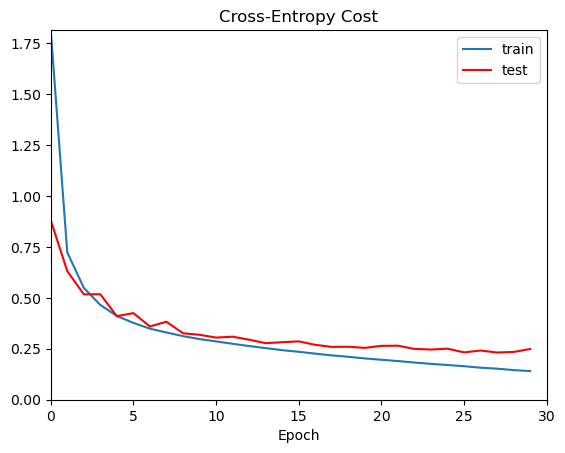

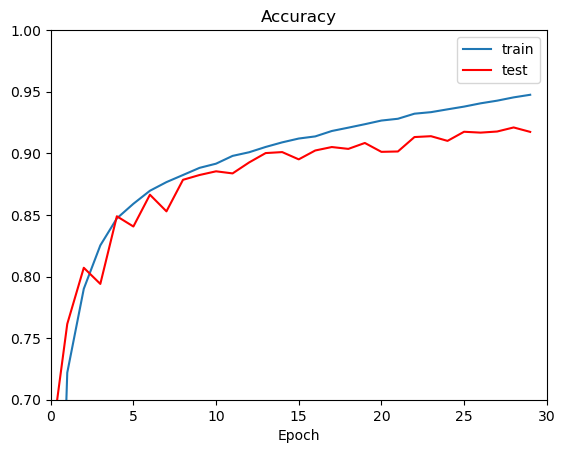

In [12]:
plot_training(nepochs, cost_hist1, cost_hist_test1, acc_hist1, acc_hist_test1, minacc=0.7)

### Adam

In [13]:
nbatch = 64
nepochs = 30
learning_rate = 0.001 #default in pytorch

model = CNN()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

adam = torch.optim.Adam(model.parameters(), lr=learning_rate)

cost_hist_do2, cost_hist_test_do2, acc_hist_do2, acc_hist_test_do2 = train_val(model, cost_ce, nepochs, train_loader, test_loader, adam, device)

Epoch 0: 0.482408, 0.343274, 0.821033, 0.872300
Epoch 1: 0.280778, 0.273528, 0.896183, 0.896700
Epoch 2: 0.233505, 0.240407, 0.914033, 0.911000
Epoch 3: 0.205616, 0.226690, 0.924467, 0.918600
Epoch 4: 0.182616, 0.225675, 0.932233, 0.919000
Epoch 5: 0.163905, 0.220110, 0.938750, 0.923300
Epoch 6: 0.146493, 0.208792, 0.945650, 0.930300
Epoch 7: 0.128465, 0.234427, 0.952317, 0.922000
Epoch 8: 0.116042, 0.218486, 0.957167, 0.927100
Epoch 9: 0.100303, 0.231741, 0.962133, 0.925400
Epoch 10: 0.086500, 0.232078, 0.967733, 0.931500
Epoch 11: 0.075589, 0.247011, 0.971417, 0.930200
Epoch 12: 0.069780, 0.274610, 0.973500, 0.928300
Epoch 13: 0.058612, 0.306749, 0.977667, 0.925800
Epoch 14: 0.050703, 0.297887, 0.981083, 0.928300
Epoch 15: 0.048374, 0.321156, 0.981917, 0.927000
Epoch 16: 0.041423, 0.324833, 0.984450, 0.925000
Epoch 17: 0.040580, 0.375884, 0.984717, 0.926300
Epoch 18: 0.038551, 0.401396, 0.986150, 0.921700
Epoch 19: 0.034271, 0.424704, 0.987400, 0.927000
Epoch 20: 0.033042, 0.358925, 

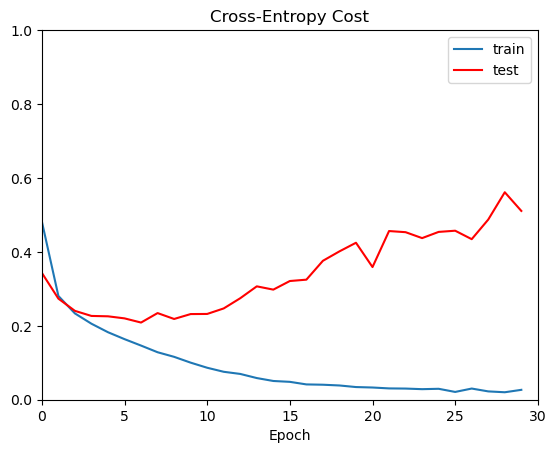

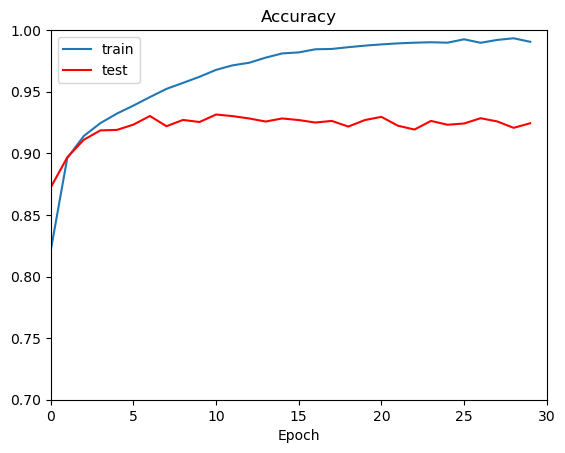

In [14]:
plot_training(nepochs, cost_hist_do2, cost_hist_test_do2, acc_hist_do2, acc_hist_test_do2, minacc=0.7)

In [18]:
def plot_two_runs(nepochs, cost_hist1, cost_hist_test1, cost_hist2, cost_hist_test2, title, low, high):
    epochs = torch.arange(nepochs)
    plt.plot(epochs, cost_hist1, "-", label='train 1')
    plt.plot(epochs, cost_hist_test1, "r-", label='test 1')
    plt.plot(epochs, cost_hist2, "--", label='train 2')
    plt.plot(epochs, cost_hist_test2, "r--", label='test 2')
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(low, high)
    plt.title(title)
    #plt.legend()

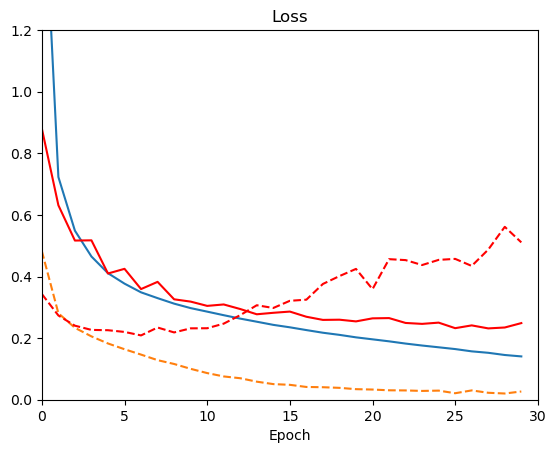

In [19]:
plot_two_runs(nepochs, cost_hist1, cost_hist_test1, cost_hist_do2, cost_hist_test_do2, "Loss", 0,1.2)

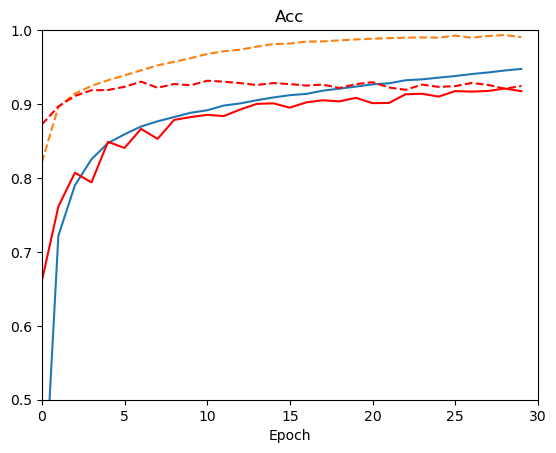

In [20]:
plot_two_runs(nepochs, acc_hist1, acc_hist_test1, acc_hist_do2, acc_hist_test_do2, "Acc", 0.5, 1.0)